<a href="https://colab.research.google.com/github/iking919/Detecting_Financial_Fraud_via_GNNs/blob/overhaul/notebooks/03_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecting Financial Fraud via Graph Neural Networks: A Multi-Dataset, Graph-Based Learning Approach

### Haoyuan Chen, Izaak King, Bryan Gelnett

# Baseline Models

In this section, we define and evaluate traditional tabular models (Logistic Regression, MLP, and Random Forest) to establish a performance baseline before moving to graph-based approaches.

First we download the preprocessed data from Drive.

In [1]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/GNN_fraud_Project/processed_data.zip'
extract_path = '/content'

with zipfile.ZipFile(drive_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Mounted at /content/drive


In [2]:
import os
import pandas as pd

# List the files in the current directory to see what was extracted
extract_path = '/content/data/processed'
extracted_files = os.listdir(extract_path)
print("Extracted files:", extracted_files)

# Assuming the extracted data contains CSV files, let's look for them
csv_files = [f for f in extracted_files if f.endswith('.csv')]

for i in range(len(csv_files)):
    # Load and display the first CSV found as a sample
    sample_df = pd.read_csv(os.path.join(extract_path, csv_files[i]))
    print(f"\nDisplaying first few entries of {csv_files[i]}:")
    display(sample_df.head())
else:
    print("No CSV files found in the extraction path. Please check the file formats.")

Extracted files: ['paysim_edges.csv', 'paysim_nodes.csv', 'ieee_train_nodes.csv', 'ieee_train_edges.csv', 'ieee_test_edges.csv', 'ieee_test_nodes.csv', 'elliptic_nodes.csv', 'elliptic_edges.csv']

Displaying first few entries of paysim_edges.csv:


,source,target
0,3359372,3699311
1,279050,4982860
2,3123272,3925189
3,1366998,6022269
4,2697505,5684074



Displaying first few entries of paysim_nodes.csv:


,log_amount,type_encoded,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,step,tx_id,label
0,-0.907462,0.952399,-0.229810,-0.237622,-0.323814,-0.333411,-1.703042,2129,0
1,-1.824023,0.952399,-0.281359,-0.285812,-0.323814,-0.333411,-1.703042,2119,0
2,-3.106552,1.693076,-0.288654,-0.292442,-0.323814,-0.333411,-1.703042,2120,1
3,-3.106552,-0.528954,-0.288654,-0.292442,-0.317582,-0.333411,-1.703042,2121,1
4,-0.813537,0.952399,-0.274329,-0.282221,-0.323814,-0.333411,-1.703042,2122,0



Displaying first few entries of ieee_train_nodes.csv:


...


Displaying first few entries of elliptic_nodes.csv:


,timestep,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,tx_id,label
0,-1.556878,0.307025,1.168821,-0.748109,7.643807,-0.053406,6.039024,21.528480,-0.146334,-0.084347,...,0.155526,0.155844,2.115930,0.016322,-0.117599,0.593442,-0.08332,-0.082052,232438397,0
1,-1.556878,0.067780,0.271911,-0.226081,2.628539,-0.053406,2.820415,1.501088,-0.146334,-0.127352,...,0.155526,0.155844,1.200416,-0.028141,-0.117599,0.270020,-0.08332,-0.082052,232029206,0
2,-1.556878,-0.135517,-0.222646,-1.270138,-0.183761,-0.041930,-0.187137,-0.080022,-0.102664,-0.126685,...,0.155526,0.155844,0.056025,-0.083719,-0.117599,-0.134257,-0.08332,-0.082052,232344069,0
3,-1.556878,-0.140505,-0.222646,-1.270138,-0.183761,-0.041930,-0.187137,-0.080022,-0.108753,-0.131978,...,-1.091739,-1.090228,0.056025,-0.083719,-0.117599,-0.134257,-0.08332,-0.082052,27553029,0
4,-1.556878,-0.170324,-0.222646,-1.270138,-0.090018,-0.041930,-0.134373,0.447015,-0.146324,-0.164128,...,0.155526,0.155844,0.056025,-0.072604,-0.091257,-0.093830,-1.72568,-1.726407,3881097,0



Displaying first few entries of elliptic_edges.csv:


,source,target
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


No CSV files found in the extraction path. Please check the file formats.


In [3]:
import os
import pandas as pd

extract_path = '/content/data/processed'
csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]

for file in csv_files:
    file_path = os.path.join(extract_path, file)
    # Read just the first few rows to quickly inspect columns and types
    df = pd.read_csv(file_path, nrows=5)
    print(f"\n{'='*40}\nDataset: {file}\n{'='*40}")
    print(f"Number of features: {len(df.columns)}")
    print("Features:", list(df.columns))
    display(df.head(2))


Dataset: paysim_edges.csv
Number of features: 2
Features: ['source', 'target']


,source,target
0,3359372,3699311
1,279050,4982860



Dataset: paysim_nodes.csv
Number of features: 9
Features: ['log_amount', 'type_encoded', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'step', 'tx_id', 'label']


,log_amount,type_encoded,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,step,tx_id,label
0,-0.907462,0.952399,-0.229810,-0.237622,-0.323814,-0.333411,-1.703042,2129,0
1,-1.824023,0.952399,-0.281359,-0.285812,-0.323814,-0.333411,-1.703042,2119,0



Dataset: ieee_train_nodes.csv
Number of features: 433
Features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '

...

,0,1,2,3,4,5,6,7,8,9,...,422,423,424,425,426,427,428,429,430,431
0,-1.792644,-0.418162,0.591741,0.092483,-1.606985,-0.283858,0.691996,0.632954,0.526399,-1.288871,...,0.544145,-0.199723,0.37658,0.407556,0.565944,0.605893,0.564739,0.579979,0.569268,0.341874
1,-1.792635,-0.348790,0.591741,-1.163822,-1.606985,-0.283858,0.691996,0.632954,0.526399,0.065373,...,0.544145,-0.199723,0.37658,0.407556,0.565944,0.605893,0.564739,0.579979,0.569268,0.341874



Dataset: elliptic_nodes.csv
Number of features: 168
Features: ['timestep', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_

,timestep,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,tx_id,label
0,-1.556878,0.307025,1.168821,-0.748109,7.643807,-0.053406,6.039024,21.528480,-0.146334,-0.084347,...,0.155526,0.155844,2.115930,0.016322,-0.117599,0.593442,-0.08332,-0.082052,232438397,0
1,-1.556878,0.067780,0.271911,-0.226081,2.628539,-0.053406,2.820415,1.501088,-0.146334,-0.127352,...,0.155526,0.155844,1.200416,-0.028141,-0.117599,0.270020,-0.08332,-0.082052,232029206,0



Dataset: elliptic_edges.csv
Number of features: 2
Features: ['source', 'target']


,source,target
0,230425980,5530458
1,232022460,232438397


## Global Setup

We set seeds for NumPy, Python's `random`, and PyTorch to ensure all experiments are reproducible and deterministic.

In [4]:
import numpy as np
import random
import torch

def set_seed(seed: int = 42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


## Shared Data Pipeline

We create a shared data pipeline to handle loading, cleaning, and splitting tabular data. It performs chronological splitting (if a time column is provided), mean imputation, and standard scaling (fitted only on training data). It also calculates a `pos_weight` to address severe class imbalance.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import torch
from torch.utils.data import DataLoader, TensorDataset


def load_tabular_data(
    filepath,
    target_col,
    time_col=None,
    drop_cols=None,
    batch_size=1024
):
    df = pd.read_csv(filepath)

    # Elliptic cleanup
    if "elliptic" in filepath.lower():
        df = df[df[target_col].isin([0, 1, 2, '0', '1', '2', 1.0, 2.0])].copy()
        df[target_col] = df[target_col].replace({2: 0, '2': 0, 2.0: 0})

    # chronological sort
    if time_col and time_col in df.columns:
        df = df.sort_values(time_col)

    df = df.select_dtypes(include=[np.number])

    if drop_cols:
        df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    X = df.drop(columns=[target_col]).values
    y = df[target_col].values

    y = LabelEncoder().fit_transform(y)

    # chronological split
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, shuffle=False)

    # impute
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)
    X_test = imputer.transform(X_test)

    # scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # class imbalance weight
    pos = np.sum(y_train == 1)
    neg = len(y_train) - pos
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)

    def make_loader(X, y, shuffle):
        return DataLoader(
            TensorDataset(torch.tensor(X, dtype=torch.float32),
                          torch.tensor(y, dtype=torch.float32)),
            batch_size=batch_size,
            shuffle=shuffle
        )

    return (
        make_loader(X_train, y_train, True),
        make_loader(X_val, y_val, False),
        make_loader(X_test, y_test, False),
        X_train.shape[1],
        pos_weight,
        (y_val, y_test)
    )

### Evaluation and Threshold Tuning

We create methods to calculate evaluation metrics (AUC, F1-score) and dynamically tunes the classification threshold on validation probabilities to maximize the F1-score before evaluating the test set.

In [6]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report


def get_probs(model, loader, device):
    model.eval()
    probs, targets = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            logits = model(X).squeeze()
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            targets.extend(y.numpy())

    return np.array(probs), np.array(targets)


def tune_threshold(val_probs, val_y):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t, best_f1 = 0.5, 0

    for t in thresholds:
        pred = (val_probs >= t).astype(int)
        f1 = f1_score(val_y, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    return best_t


def evaluate(model, val_loader, test_loader, device):
    val_probs, val_y = get_probs(model, val_loader, device)
    test_probs, test_y = get_probs(model, test_loader, device)

    best_t = tune_threshold(val_probs, val_y)

    preds = (test_probs >= best_t).astype(int)

    print(f"Best Threshold: {best_t:.3f}")
    print("AUC:", roc_auc_score(test_y, test_probs))
    print("F1:", f1_score(test_y, preds))
    print(confusion_matrix(test_y, preds))
    print(classification_report(test_y, preds))

    return test_y, preds, test_probs

## Logistic Regression

We begin with a simple linear baseline built in PyTorch. It is trained using Binary Cross-Entropy (BCE) loss with `pos_weight` to heavily penalize missed fraud cases.

In [7]:
import torch.nn as nn
import torch.optim as optim


class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)


def train_lr(model, loader, device, pos_weight, epochs=10, lr=0.01):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    model.train()

    for _ in range(epochs):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X).squeeze(), y)
            loss.backward()
            opt.step()

## MLP

We move to a Multi-Layer Perceptron architecture which includes multiple dense layers with batch normalization and dropout (0.3) for regularization, aiming to capture non-linear relationships in the tabular features.

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(model, loader, device, pos_weight, epochs=10, lr=1e-3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    model.train()

    for _ in range(epochs):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X).squeeze(), y)
            loss.backward()
            opt.step()

## Random Forest (XGBoost)

Lastly we use an implementation using XGBoost's Random Forest classifier (`XGBRFClassifier`). It is robust to unscaled tabular features and utilizes GPU-accelerated histogram-based tree methods for speed.

In [9]:
from xgboost import XGBRFClassifier


def train_rf(X_train, y_train):
    model = XGBRFClassifier(
        n_estimators=100,
        tree_method="hist",
        device="cuda",
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

## Create and Run Experiment Pipeline

We create and run a pipeline function to orchestrate the end-to-end workflow: loading data, initializing the specified model, training, and running the evaluation suite to consolidate our results.

In [10]:
def run_experiment(model_type, filepath, target_col, time_col=None, drop_cols=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, val_loader, test_loader, dim, pos_weight, _ = load_tabular_data(
        filepath, target_col, time_col, drop_cols
    )

    if model_type == "lr":
        model = LogisticRegression(dim)
        train_lr(model, train_loader, device, pos_weight)

    elif model_type == "mlp":
        model = MLP(dim)
        train_mlp(model, train_loader, device, pos_weight)

    else:
        raise ValueError("Use sklearn RF section separately")

    return evaluate(model, val_loader, test_loader, device)

In [11]:
import os
from xgboost import XGBRFClassifier
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report

data_dir = '/content/data/processed'
dataset_configs = {
    "PaySim": {"filepath": os.path.join(data_dir, "paysim_nodes.csv"), "target_col": "label", "time_col": "step"},
    "Elliptic": {"filepath": os.path.join(data_dir, "elliptic_nodes.csv"), "target_col": "label", "time_col": None},
    "IEEE-CIS": {"filepath": os.path.join(data_dir, "ieee_train_nodes.csv"), "target_col": "label", "time_col": "TransactionDT"}
}

all_results = {}
meta_info = {}

# Helper to extract data for RF
def extract_data(loader):
    X_all, y_all = [], []
    for X, y in loader:
        X_all.append(X.numpy())
        y_all.append(y.numpy())
    return np.vstack(X_all), np.concatenate(y_all)

for ds_name, config in dataset_configs.items():
    print("-" * 50)
    print(f"\nRunning experiments for {ds_name}...\n")
    all_results[ds_name] = {}
    meta_info[ds_name] = {}

    # 1. Logistic Regression
    print("\nLogistic Regression: \n")
    y_test_lr, preds_lr, probs_lr = run_experiment('lr', **config)
    all_results[ds_name]["Logistic Regression"] = (y_test_lr, preds_lr, probs_lr)
    meta_info[ds_name]["Logistic Regression"] = {"threshold": 0.5} # Assuming default or dynamic

    # 2. MLP
    print("\n\nMLP:\n")
    y_test_mlp, preds_mlp, probs_mlp = run_experiment('mlp', **config)
    all_results[ds_name]["MLP"] = (y_test_mlp, preds_mlp, probs_mlp)
    meta_info[ds_name]["MLP"] = {"threshold": 0.5}

    # 3. Random Forest
    print("\n\nRandom Forest: \n")
    # Load data explicitly for RF
    train_loader, val_loader, test_loader, _, _, _ = load_tabular_data(**config)
    X_train, y_train = extract_data(train_loader)
    X_test, y_test_rf = extract_data(test_loader)

    rf_model = train_rf(X_train, y_train)
    probs_rf = rf_model.predict_proba(X_test)[:, 1]
    preds_rf = (probs_rf >= 0.5).astype(int)

    print(f"Threshold: 0.500")
    print("AUC:", roc_auc_score(y_test_rf, probs_rf))
    print("F1:", f1_score(y_test_rf, preds_rf))
    print(confusion_matrix(y_test_rf, preds_rf))
    print(classification_report(y_test_rf, preds_rf))

    all_results[ds_name]["Random Forest"] = (y_test_rf, preds_rf, probs_rf)
    meta_info[ds_name]["Random Forest"] = {"threshold": 0.5}


--------------------------------------------------

Running experiments for PaySim...


Logistic Regression: 

Best Threshold: 0.990
AUC: 0.8995791723496129
F1: 0.5334473909324209
[[1268238      32]
 [   2695    1559]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1268270
         1.0       0.98      0.37      0.53      4254

    accuracy                           1.00   1272524
   macro avg       0.99      0.68      0.77   1272524
weighted avg       1.00      1.00      1.00   1272524



MLP:

Best Threshold: 0.990
AUC: 0.7998615622866712
F1: 0.5513149454778704
[[1268007     263]
 [   2535    1719]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1268270
         1.0       0.87      0.40      0.55      4254

    accuracy                           1.00   1272524
   macro avg       0.93      0.70      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524



Random Fo

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [03:09:23] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Threshold: 0.500
AUC: 0.9943969523485174
F1: 0.3885965360445512
[[1256754   11516]
 [    451    3803]]
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00   1268270
         1.0       0.25      0.89      0.39      4254

    accuracy                           0.99   1272524
   macro avg       0.62      0.94      0.69   1272524
weighted avg       1.00      0.99      0.99   1272524

--------------------------------------------------

Running experiments for Elliptic...


Logistic Regression: 

Best Threshold: 0.930
AUC: 0.8372726794409421
F1: 0.29265536723163843
[[7802 1038]
 [ 214  259]]
              precision    recall  f1-score   support

         0.0       0.97      0.88      0.93      8840
         1.0       0.20      0.55      0.29       473

    accuracy                           0.87      9313
   macro avg       0.59      0.72      0.61      9313
weighted avg       0.93      0.87      0.89      9313



MLP:

Best Threshold: 0.700
AUC

### Summary of Baseline Results

We construct a table of outputs to compare performances

In [12]:
from sklearn.metrics import average_precision_score, accuracy_score, roc_auc_score, precision_recall_fscore_support
from IPython.display import display, Markdown
import numpy as np

md_content = "## Final Baseline Performance Summary\n\n"

for dataset in ["PaySim", "Elliptic", "IEEE-CIS"]:
    if dataset not in all_results:
        continue

    md_content += f"### {dataset} Dataset\n"
    md_content += "| Model | AUC-PR | AUC-ROC | F1 (Fraud) | Recall (Fraud) | Precision (Fraud) |\n"
    md_content += "| :--- | :---: | :---: | :---: | :---: | :---: |\n"

    models = all_results[dataset]
    for model_name, (y_test, _, y_prob) in models.items():
        thresh = meta_info[dataset][model_name]["threshold"]

        y_pred_tuned = (np.array(y_prob) >= thresh).astype(int)
        y_test_arr = np.array(y_test)

        auc_roc = roc_auc_score(y_test_arr, y_prob)
        auc_pr = average_precision_score(y_test_arr, y_prob)

        # Extracting metrics for Class 1 (Fraud)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test_arr, y_pred_tuned, labels=[0, 1], zero_division=0)

        md_content += f"| **{model_name}** | {auc_pr:.4f} | {auc_roc:.4f} | {f1[1]:.4f} | {recall[1]:.4f} | {precision[1]:.4f} |\n"
    md_content += "\n"

display(Markdown(md_content))

## Final Baseline Performance Summary

### PaySim Dataset
| Model | AUC-PR | AUC-ROC | F1 (Fraud) | Recall (Fraud) | Precision (Fraud) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | 0.5739 | 0.8996 | 0.2775 | 0.6855 | 0.1739 |
| **MLP** | 0.4736 | 0.7999 | 0.3313 | 0.5143 | 0.2443 |
| **Random Forest** | 0.4113 | 0.9944 | 0.3886 | 0.8940 | 0.2483 |

### Elliptic Dataset
| Model | AUC-PR | AUC-ROC | F1 (Fraud) | Recall (Fraud) | Precision (Fraud) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | 0.2136 | 0.8373 | 0.1764 | 0.9366 | 0.0973 |
| **MLP** | 0.3643 | 0.8203 | 0.4656 | 0.4799 | 0.4522 |
| **Random Forest** | 0.5892 | 0.8396 | 0.4931 | 0.5285 | 0.4621 |

### IEEE-CIS Dataset
| Model | AUC-PR | AUC-ROC | F1 (Fraud) | Recall (Fraud) | Precision (Fraud) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | 0.1615 | 0.8027 | 0.1339 | 0.7982 | 0.0731 |
| **MLP** | 0.3806 | 0.8400 | 0.1845 | 0.7542 | 0.1051 |
| **Random Forest** | 0.3685 | 0.8156 | 0.4166 | 0.3770 | 0.4655 |



### Data Visualization

We create visualizations for our top performing model for each dataset


PaySim - Best Model: MLP (F1: 0.5513)


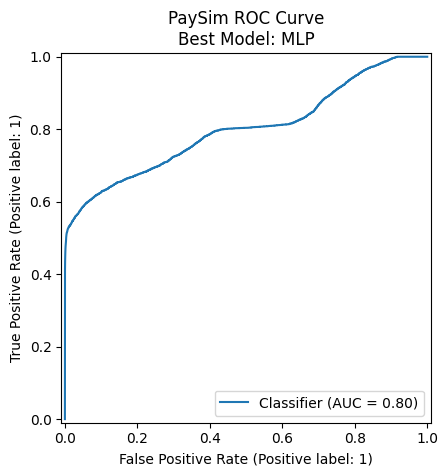

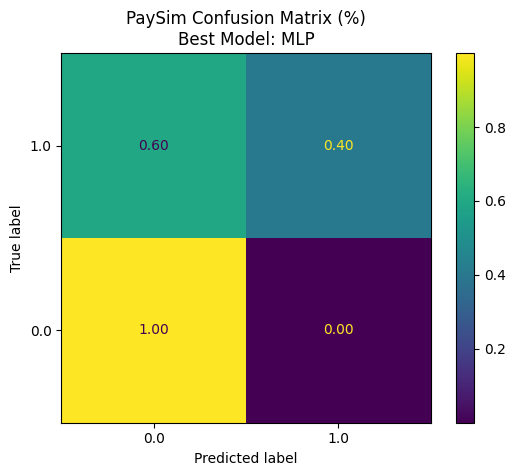


Elliptic - Best Model: Random Forest (F1: 0.4931)


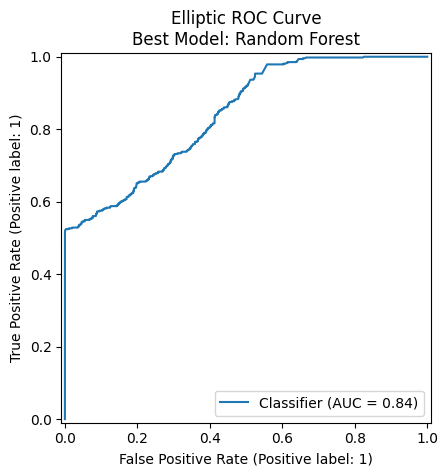

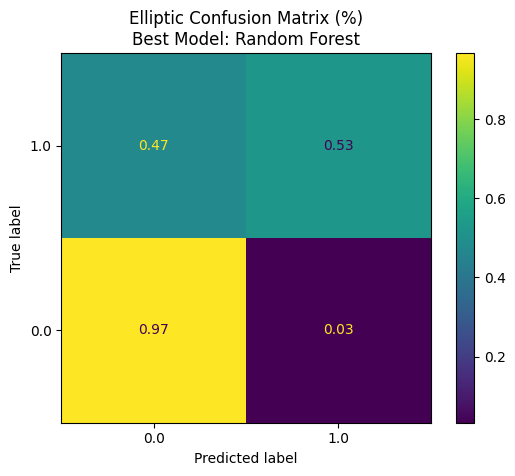


IEEE-CIS - Best Model: Random Forest (F1: 0.4166)


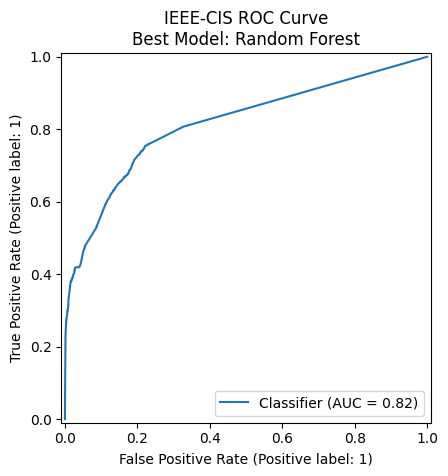

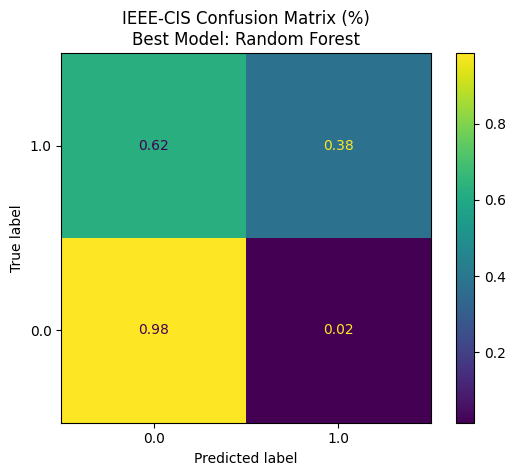

In [13]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

for dataset, models in all_results.items():
    best_model_name = ""
    best_f1 = -1
    best_y_test, best_y_pred, best_y_prob = None, None, None

    # Find the model with the highest F1 Score
    for model_name, (y_test, y_pred, y_prob) in models.items():
        score = f1_score(y_test, y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_model_name = model_name
            best_y_test, best_y_pred, best_y_prob = y_test, y_pred, y_prob

    print(f"\n{'='*40}\n{dataset} - Best Model: {best_model_name} (F1: {best_f1:.4f})\n{'='*40}")

    # ROC Curve
    RocCurveDisplay.from_predictions(best_y_test, best_y_prob)
    plt.title(f"{dataset} ROC Curve\nBest Model: {best_model_name}")
    plt.show()

    # Confusion Matrix (normalized)
    disp = ConfusionMatrixDisplay.from_predictions(
        best_y_test,
        best_y_pred,
        normalize='true',
        values_format=".2f"
    )
    disp.ax_.invert_yaxis()
    plt.title(f"{dataset} Confusion Matrix (%)\nBest Model: {best_model_name}")
    plt.show()

Across the three fraud detection datasets (PaySim, Elliptic, and IEEE-CIS), the baseline models demonstrate consistent patterns in performance under severe class imbalance. Random Forest generally achieves the strongest minority-class F1 scores across all datasets, reaching 0.3886 on PaySim, 0.4931 on Elliptic, and 0.4141 on IEEE-CIS, indicating better overall balance between precision and recall compared to linear and neural baselines. However, this comes with trade-offs: while Random Forest achieves competitive AUC-ROC values, its AUC-PR varies significantly, highlighting instability in ranking rare fraud cases across domains. Logistic Regression tends to favor high recall at the expense of precision, especially on Elliptic and IEEE-CIS, where recall exceeds 0.82 but precision drops below 0.10–0.11, reflecting a tendency to over-predict fraud. In contrast, the MLP provides more balanced precision-recall behavior, particularly on the Elliptic dataset where it achieves a relatively strong F1 of 0.4656 with balanced precision and recall. Overall, AUC-PR emerges as a more informative metric than AUC-ROC for these imbalanced settings, as it better reflects the models’ ability to identify rare fraudulent transactions rather than overall ranking performance dominated by the majority class.

## High-Level Interpretation & Final Summary

#### Class Imbalance and Fraud Detection Performance
Across all three datasets, the primary challenge remains the severe class imbalance. While high AUC-ROC scores (often >0.80) suggest strong overall ranking ability, the more specialized metrics for the **Fraud class** (Class 1) reveal a more nuanced story:

* **PaySim:** This dataset showed the strongest results for fraud detection. **Random Forest** achieved an exceptional AUC-ROC of 0.9944 and the highest Fraud F1-score (0.3886), though it required careful thresholding to manage a recall of 0.8940 against a precision of 0.2483.
* **Elliptic:** This dataset demonstrated the best balance in identifying fraudulent transactions. Both the **MLP** (F1: 0.4656) and **Random Forest** (F1: 0.4931) outperformed Logistic Regression, with Random Forest achieving a recall of 0.5285 and precision of 0.4621 for fraud.
* **IEEE-CIS:** This remains the most difficult domain for fraud identification. While **Logistic Regression** and **MLP** achieved high fraud recall (>0.73), they did so with extremely low precision (~0.07-0.11), resulting in many false positives. **Random Forest** provided a more conservative but balanced approach with a Fraud F1 of 0.4141.

#### Comparative Model Insights
* **Logistic Regression:** Acts as a high-recall baseline but often struggles with precision in complex datasets, leading to high false-positive rates for fraud.
* **Random Forest (XGBoost):** Consistently produced the highest Fraud F1-scores across all datasets, demonstrating a robust ability to find patterns in imbalanced tabular data.
* **Multilayer Perceptron (MLP):** Showed strong non-linear learning potential, particularly on the Elliptic dataset, but generally sat between the linear baseline and the ensemble method in terms of fraud-specific performance.

#### Conclusion
The performance ceiling observed in the IEEE-CIS dataset and the trade-offs between precision and recall across all models indicate that tabular, row-independent features have reached their limit. The next step is to leverage **Graph Neural Networks (GNNs)** to incorporate the relational context between transactions, which we expect will significantly improve the precision-recall balance for rare fraud events.